In [31]:
from treeswift import * 
from laml_libs.sequence_lib import read_sequences, read_priors
from treeswift import read_tree_newick
import pandas as pd

dirname = "/Users/gc3045/scmail_v1/sc-mail-experiments/Real_biodata/TLSCL/evaluation/Bar12"

In [125]:
laml_tree_file = "/Users/gc3045/scmail_v1/sc-mail-experiments/Real_biodata/TLSCL/evaluation/AM-DNA-097/LAML_casshybridstart_LAMLrep4_AM-DNA-097_rep15_scaled_trees.nwk"
cassh_tree_file = "/Users/gc3045/scmail_v1/sc-mail-experiments/Real_biodata/TLSCL/evaluation/AM-DNA-097/AM-DNA-097_hybrid_newick_noMutationlessEdges.txt"
startle_tree_file = "/Users/gc3045/scmail_v1/sc-mail-experiments/Real_biodata/TLSCL/evaluation/AM-DNA-097/AM-DNA-097_startlenni_tree_binary.newick"
metadata_file = "/Users/gc3045/scmail_v1/sc-mail-experiments/Real_biodata/TLSCL/evaluation/AM-DNA-097/AM-DNA-097_metadata.txt"


In [126]:
laml_t = read_tree_newick(laml_tree_file)
cass_t = read_tree_newick(cassh_tree_file)
leaf_set = [x.label for x in laml_t.traverse_leaves()]
t = cass_t.extract_tree_with(leaf_set)
df = pd.read_csv(metadata_file, delimiter='\t')
df.index = df['cellBC']

In [34]:
df.cell_state.unique()

array(["['Endothelial']", "['Somite0']", "['NMPs']", "['NeuralTube1']",
       "['SomiteDermo']", "['NeuralTube2']", "['SomiteSclero']",
       "['Somite']", "['aPSM']", "['PCGLC']", "['Somite-1']",
       "['Endoderm']", "['pPSM']", "['Unknown']"], dtype=object)

In [35]:
import ast

for index, row in df.iterrows(): 
    # cell_state = ast.literal_eval(df.loc['TTTCATGCAGCACGAA-1','cell_state'])
    cell_state = ast.literal_eval(row['cell_state'])

    print(cell_state)

['Endothelial']
['Somite0']
['NMPs']
['NeuralTube1']
['SomiteDermo']
['SomiteDermo']
['NeuralTube2']
['NMPs']
['SomiteDermo']
['NeuralTube2']
['NeuralTube1']
['SomiteDermo']
['SomiteSclero']
['NeuralTube1']
['SomiteSclero']
['SomiteSclero']
['Somite']
['NMPs']
['Somite0']
['SomiteSclero']
['SomiteSclero']
['NeuralTube1']
['Somite']
['SomiteDermo']
['NeuralTube2']
['SomiteDermo']
['SomiteDermo']
['NMPs']
['NeuralTube2']
['NMPs']
['SomiteSclero']
['SomiteSclero']
['SomiteSclero']
['SomiteSclero']
['NeuralTube2']
['NeuralTube2']
['SomiteDermo']
['Somite']
['aPSM']
['SomiteSclero']
['SomiteSclero']
['Somite']
['Somite']
['SomiteSclero']
['SomiteDermo']
['NeuralTube2']
['PCGLC']
['NMPs']
['NeuralTube1']
['NeuralTube2']
['SomiteDermo']
['SomiteSclero']
['SomiteSclero']
['Somite-1']
['SomiteSclero']
['Somite-1']
['SomiteDermo']
['NMPs']
['SomiteDermo']
['NeuralTube2']
['SomiteDermo']
['SomiteSclero']
['aPSM']
['SomiteSclero']
['Somite-1']
['Somite0']
['NeuralTube2']
['NeuralTube2']
['PCGLC']


In [76]:
# resolution 5
# dev_tree_str = '((PCGLC:1,(Endothelial:1,(Endoderm:1,((NeuralTube2:0)NeuralTube1:1,(((((SomiteDermo:0,SomiteSclero:0)Somite:0)Somite0:0)Somite-1:0)aPSM:0)pPSM:0)NMPs:1)Prog-derm-NMPs:1)Prog-lial-derm:1)Prog-PGCLC-lial:1)Prog:0;'

# resolution 17
dev_tree_str = '((PCGLC:1,(Endothelial:1,(Endoderm:1,((NeuralTube2:1)NeuralTube1:1,(((((SomiteDermo:1,SomiteSclero:1)Somite:1)Somite0:1)Somite-1:1)pPSM:1)aPSM:1)NMPs:1)Prog-derm-NMPs:1)Prog-lial-derm:1)Prog-PGCLC-lial:1)Prog:0;'

dev_tree = read_tree_newick(dev_tree_str)
cell_states = [x.label for x in dev_tree.traverse_levelorder()]

In [77]:
dev_tree.num_nodes()

17

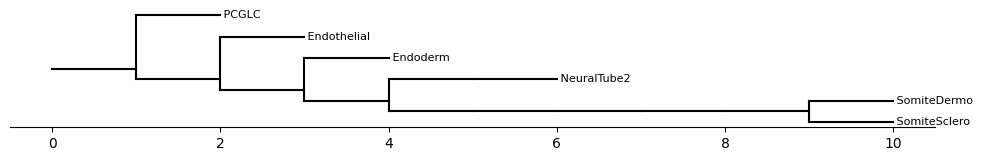

In [78]:
dev_tree.draw(show_labels=True, show_plot=True,
              export_filename="/Users/gc3045/scmail_v1/sc-mail-experiments/Real_biodata/TLSCL/dev_tree.pdf", xlabel=None)

In [79]:
transition_dict = {}

mrca, cost, transition_dict = get_lca(dev_tree, ['SomiteDermo', 'NeuralTube2'], transition_dict)
mrca.label, cost, transition_dict

('NMPs', 8.0, {('NMPs', 'SomiteDermo'): 1, ('NMPs', 'NeuralTube2'): 1})

In [80]:
# get LCA assignment given cell states
def get_lca(tree, states, transitions):
    mrca = tree.mrca(states)
    for state in states:
        if not tree.find_node(state, internal=True, leaves=True):
            print(state, "couldn't find node in dev tree")
        if (mrca.label, state) not in transitions.keys():
            transitions[mrca.label, state] = 0
        transitions[mrca.label, state] += 1
        
    cost = sum([tree.distance_between(mrca, tree.find_node(state, internal=True, leaves=True)) for state in states if tree.find_node(state, internal=True, leaves=True)])
    
    return mrca, cost, transitions

def get_cost(dev_tree, u, t):
    '''Assumes u is the ancestor and t is the descendent'''
    cost = 0
    if not dev_tree.find_node(t, internal=True, leaves=True) or not dev_tree.find_node(u, internal=True, leaves=True):
        return cost
    if t == u:
        return cost
    t = dev_tree.find_node(t, internal=True, leaves=True)
    u = dev_tree.find_node(u, internal=True, leaves=True)
    for anc in t.traverse_ancestors(include_self=True):
        if anc == u:
            return cost
        else:
            cost += anc.get_edge_length()
            
    cost = float('inf')
    return cost

In [81]:
current_t = laml_t
current_t

In [82]:
[x.edge_length for x in current_t.root.children]

[1.1297068576614993]

In [83]:
i = 0
for node in current_t.traverse_postorder(leaves=True, internal=True):
    if node.label is None or node.label == '':
        node.label = f"node_{i}"
        i += 1
for node in current_t.traverse_postorder(leaves=True, internal=True):
    if node.label is None or node.label == '':
        print("huh")
    else:
        print(node.label)

TTCATTGGTTAGAGAT-1
GTTGCTCTCGGATAAA-1
node_0
GCAACATGTTCATCTT-1
node_1
TAGGAGGAGCCGTAAG-1
ATTGGGTTCGTGGTAT-1
node_2
node_3
TGGTAGTCAATGTGGG-1
node_4
CGAAGTTCACGCGTGT-1
node_5
AGTGACTGTCCACTTC-1
node_6
AGACTCACAGTGTATC-1
node_7
AAACGCTAGTAACGTA-1
TTCAATCGTACGTGAG-1
CCAATGATCCTCAGGG-1
node_8
node_9
AAGCGAGTCAAACTGC-1
TGCGGCAAGAAACACT-1
node_10
CTCCAACAGTTCATGC-1
node_11
node_12
CTGCTCAGTGCACATT-1
GCATGATAGGGATCGT-1
node_13
TGAGGGACACCGAATT-1
ATGCATGTCCGGTAGC-1
node_14
TCATTGTGTCCAATCA-1
TTAGGGTGTCCTTTGC-1
node_15
node_16
node_17
TCATCCGAGACCAGCA-1
ACCAACATCAAGCCAT-1
ACAAGCTTCGCTCATC-1
node_18
node_19
GATTCTTCAGTAGGAC-1
GTAAGTCAGTGGCAGT-1
node_20
ATTCTACAGCCGTCGT-1
node_21
CGCAGGTGTTCGTACA-1
TATATCCGTCACAGTT-1
node_22
GGCAGTCTCGTGGGTC-1
node_23
TCCCACACAGACCAGA-1
node_24
node_25
node_26
node_27
CTTCTAAAGGTCCGAA-1
node_28
CAGCACGGTTATGACC-1
node_29
TCAGCCTAGTTTGGCT-1
TCCAGAACAGAGCGTA-1
node_30
ACTGTGAGTACCGTCG-1
GATCATGTCACCTGTC-1
node_31
GCTACAAGTGAATAAC-1
node_32
CAACCAAGTGTCATCA-1
node_

In [84]:
# t = tmp_t
total_cost = 0
sankoff_cost = 0
transition_dict = {}
M = {}
    
for node in current_t.traverse_postorder():
    if node.is_leaf():
        node.cell_state = ast.literal_eval(df.loc[node.label,'cell_state'])[0]
        M[node.label] = {}
        for s in cell_states:
            if s == node.cell_state or node.cell_state == 'Unknown':
                M[node.label][s] = 0
            else:
                M[node.label][s] = float('inf')
        min_state = min(M[node.label], key=lambda x: M[node.label][x])
        if M[node.label][min_state] != 0:
            print(node.label, node.cell_state, M[node.label][min_state])
        assert M[node.label][min_state] == 0
    else:
        # sankoff's
        M[node.label] = {}
        for s in cell_states:
            M[node.label][s] = 0
            for child in node.children:
                min_child_state = min(M[child.label], key=lambda x: M[child.label][x])
                
                min_cost = float('inf')
                for c_s in cell_states:
                    cost = get_cost(dev_tree, s, c_s)
                    child_cost = cost + M[child.label][c_s]
                    
                    if child_cost < min_cost:
                        min_cost = child_cost
                
                M[node.label][s] += min_cost
        
        min_cost_label = min(M[node.label], key=lambda x: M[node.label][x])
        min_cost = M[node.label][min_cost_label]
        
        if min_cost == float('inf'): # why is my state = 'Prog' ever inf?
            print(f"children leaves: {[child.is_leaf() for child in node.children]}")
            print(f"children states: {[(min(M[child.label], key=lambda x: M[child.label][x]), M[child.label][min(M[child.label], key=lambda x: M[child.label][x])]) for child in node.children]}")
            print(f"my state: {M[node.label]}")
        if node == current_t.root:
            print("min_cost", min_cost_label, min_cost)
                

min_cost Prog-PGCLC-lial 2617.0


In [85]:
total_cost = 0
transition_dict = {}
for node in current_t.traverse_postorder():
    if node.is_leaf():
        node.cell_state = ast.literal_eval(df.loc[node.label,'cell_state'])[0]
        # print("leaf cell state", node.cell_state)
    else:
        # get children
        child_cell_states = [c.cell_state for c in node.children]
        # print(child_cell_states)
        mrca, cost, transition_dict = get_lca(dev_tree, child_cell_states, transition_dict)
        node.cell_state = mrca.label
        total_cost += cost
        if node.cell_state is None:
            print(child_cell_states)
        
        # get the most common cell state transition jump

Unknown couldn't find node in dev tree
Unknown couldn't find node in dev tree
Unknown couldn't find node in dev tree
Unknown couldn't find node in dev tree
Unknown couldn't find node in dev tree
Unknown couldn't find node in dev tree
Unknown couldn't find node in dev tree
Unknown couldn't find node in dev tree
Unknown couldn't find node in dev tree
Unknown couldn't find node in dev tree
Unknown couldn't find node in dev tree


In [86]:
total_cost

2617.0

In [87]:
# check if each node has an internal label now
for node in current_t.traverse_postorder(): 
    if node.is_leaf():
        print(node.cell_state)

NeuralTube1
NeuralTube1
NeuralTube1
pPSM
NeuralTube1
Somite0
Somite-1
PCGLC
NeuralTube2
NeuralTube1
Somite0
Somite
Somite-1
Somite
SomiteDermo
Somite
SomiteSclero
Somite
Somite
SomiteSclero
Somite0
aPSM
Somite0
aPSM
SomiteDermo
Somite
NMPs
NMPs
SomiteSclero
SomiteSclero
Somite
NeuralTube1
SomiteDermo
Endoderm
Somite0
SomiteSclero
NeuralTube2
Somite
SomiteDermo
PCGLC
PCGLC
SomiteSclero
SomiteSclero
Somite
NMPs
Somite0
Somite0
SomiteDermo
Somite
aPSM
SomiteDermo
Somite0
SomiteSclero
SomiteSclero
SomiteSclero
pPSM
NMPs
Somite
SomiteDermo
SomiteSclero
SomiteDermo
SomiteSclero
NeuralTube2
NMPs
SomiteSclero
NeuralTube2
NeuralTube2
pPSM
NMPs
pPSM
SomiteSclero
NeuralTube2
NeuralTube2
NeuralTube2
NMPs
NeuralTube1
NeuralTube2
NeuralTube2
NeuralTube2
NeuralTube1
NeuralTube1
NeuralTube1
NeuralTube2
NeuralTube2
NeuralTube2
SomiteDermo
SomiteDermo
NeuralTube2
Somite
NeuralTube2
NeuralTube2
SomiteSclero
SomiteSclero
NeuralTube1
SomiteDermo
SomiteDermo
SomiteDermo
NeuralTube2
PCGLC
NeuralTube2
SomiteS

In [92]:
current_t.root.cell_state

'Prog-PGCLC-lial'

In [113]:
def tree_to_newick(root):
    subgs = []
    parent_label = root.cell_state
    for child in root.children:
        child_label = str(child.cell_state)
        weight = str(child.edge_length)
        if len(child.children) > 0:
            subgs.append(tree_to_newick(child) + f"{child_label}:{weight}[&celltype={child_label}]")
        else:
            subgs.append(child.label + f":{weight}[&celltype={child_label}]")
    return "(" + ','.join(subgs) + ")" 


In [120]:
def tree_to_newick_onlyleaves(root):
    subgs = []
    parent_label = root.cell_state
    for child in root.children:
        child_label = str(child.cell_state)
        weight = str(child.edge_length)
        if len(child.children) > 0:
            subgs.append(tree_to_newick_onlyleaves(child) + f"{child_label}:{weight}")
        else:
            subgs.append(child.label + f":{weight}[&celltype={child_label}]")
    return "(" + ','.join(subgs) + ")" 


In [114]:
tmp_t = read_tree_newick('((a,b),c);')
c = 0
for x in tmp_t.traverse_postorder():
    x.cell_state = c
    c += 1

In [115]:
for x in tmp_t.traverse_postorder():
    print(x.cell_state)

0
1
2
3
4


In [116]:
tree_to_newick(tmp_t.root)

'((a:None[&celltype=0],b:None[&celltype=1])2:None[&celltype=2],c:None[&celltype=3])'

In [91]:

# write with the annotations

current_t.write_tree_newick('/Users/gc3045/laml_experiments/rebuttal/tls_celltype/TLS1_097_inferred.nwk')

In [117]:

annotated_str = tree_to_newick(current_t.root)

with open("/Users/gc3045/laml_experiments/rebuttal/tls_celltype/TLS1_097_celltypes_res17.nwk", "w+") as w:
    w.write(annotated_str + ';\n')


In [121]:

annotated_str = tree_to_newick_onlyleaves(current_t.root)

with open("/Users/gc3045/laml_experiments/rebuttal/tls_celltype/TLS1_097_celltypes_res17.onlyleaves.nwk", "w+") as w:
    w.write(annotated_str + ';\n')


In [137]:
idx = 0
current_t = cass_t
for node in current_t.traverse_postorder():
    if node.is_leaf():
        node.cell_state = ast.literal_eval(df.loc[node.label, 'cell_state'])[0]
        node.set_edge_length(1)
    else:
        if not node.label:
            node.label = f'internal_n{idx}'
        node.cell_state = 'NA'
        node.set_edge_length(1)
        idx += 1

annotated_str = tree_to_newick_onlyleaves(current_t.root)

with open("/Users/gc3045/laml_experiments/rebuttal/tls_celltype/cassH.TLS1_097_celltypes_res17.onlyleaves.nwk", "w+") as w:
    w.write(annotated_str + ';\n')

In [138]:
annotated_str

'((((CAATACGAGATAGCAT-1:1.0[&celltype=PCGLC],((GCTTGGGAGACCACGA-1:1.0[&celltype=NeuralTube1],TTACCGCCAGGAGGAG-1:1.0[&celltype=Somite0])NA:1.0,GGAATGGAGGTCCCGT-1:1.0[&celltype=NMPs])NA:1.0,AACCTTTGTCGTGGTC-1:1.0[&celltype=SomiteDermo])NA:1.0,(((AAGGAATGTTCCTAGA-1:1.0[&celltype=NMPs],(ACGTTCCAGTACGAGC-1:1.0[&celltype=Somite],GAAACCTGTGAGGAAA-1:1.0[&celltype=Somite])NA:1.0)NA:1.0,GGACGTCAGGTCACCC-1:1.0[&celltype=Endoderm])NA:1.0,(((((TGTCCACCAAGGTACG-1:1.0[&celltype=Endoderm],GCCGTGAAGTCTAACC-1:1.0[&celltype=Endoderm])NA:1.0,GTGGCGTCACGGAAGT-1:1.0[&celltype=Endoderm])NA:1.0,(GCCGATGGTGACAACG-1:1.0[&celltype=Endoderm],(TCATTGTGTCATACCA-1:1.0[&celltype=SomiteSclero],CACGAATAGTAAGGGA-1:1.0[&celltype=NeuralTube1])NA:1.0)NA:1.0,TGGGATTTCTGAATGC-1:1.0[&celltype=SomiteSclero],TCCACGTAGTTCTCTT-1:1.0[&celltype=SomiteDermo],ATGGAGGTCCTTCGAC-1:1.0[&celltype=SomiteSclero],GCAGTTAGTATCATGC-1:1.0[&celltype=SomiteSclero],CGCCATTTCCTGTAAG-1:1.0[&celltype=NeuralTube1])NA:1.0,GACCCTTAGTATAGGT-1:1.0[&cellty